### https://github.com/alobashev/sw-guidance/

In [ ]:
conda create -n ColourDebiasingEnv python=3.10 -y


In [ ]:
git clone https://github.com/alobashev/sw-guidance.git
cd sw-guidance
pip install -r requirements.txt

In [15]:
import numpy as np
from PIL import Image

def colour_stats(path):
    img = Image.open(path).convert("RGB")
    x = np.asarray(img) / 255.0
    pixels = x.reshape(-1, 3)

    mean = pixels.mean(axis=0)
    cov = np.cov(pixels.T)
    return mean, cov

In [ ]:
mean_gen, cov_gen = colour_stats("sw-guidance/generation_v40/0.png")
mean_ref, cov_ref = colour_stats("sw-guidance/assets/pastel.jpeg")

mean_dist = np.linalg.norm(mean_gen - mean_ref)
cov_dist  = np.linalg.norm(cov_gen - cov_ref)

print("Mean distance:", mean_dist)
print("Cov distance :", cov_dist)

Mean distance: 0.028654198588432447
Cov distance : 0.011301026187001857


In [3]:
mean_gen, cov_gen = colour_stats("sw-guidance/generation_v40/_0.png")
mean_ref, cov_ref = colour_stats("sw-guidance/assets/pastel.jpeg")

mean_dist = np.linalg.norm(mean_gen - mean_ref)
cov_dist  = np.linalg.norm(cov_gen - cov_ref)

print("Mean distance:", mean_dist)
print("Cov distance :", cov_dist)

Mean distance: 0.17552118653466858
Cov distance : 0.04226283234546819


In [4]:
mean_gen, cov_gen = colour_stats("sw-guidance/generation_v40/0.png")
mean_ref, cov_ref = colour_stats("sw-guidance/assets/pastel.jpeg")

mean_dist = np.linalg.norm(mean_gen - mean_ref)
cov_dist  = np.linalg.norm(cov_gen - cov_ref)

print("Mean distance:", mean_dist)
print("Cov distance :", cov_dist)

Mean distance: 0.02317414729601218
Cov distance : 0.00971508806331969


In [16]:
mean_gen, cov_gen = colour_stats("sw-guidance/generation_v40/0.png")
mean_ref, cov_ref = colour_stats("sw-guidance/assets/pastel.jpeg")

mean_dist = np.linalg.norm(mean_gen - mean_ref)
cov_dist  = np.linalg.norm(cov_gen - cov_ref)

print("Mean distance:", mean_dist)
print("Cov distance :", cov_dist)

Mean distance: 0.01597241746099543
Cov distance : 0.01781088332701971


In [1]:
import numpy as np
from PIL import Image

def average_rgb(image_path):
    img = Image.open(image_path).convert("RGB")
    arr = np.asarray(img) / 255.0  # H x W x 3, normalized
    mean_rgb = arr.mean(axis=(0, 1))  # (R, G, B)
    return mean_rgb

def rgb_box(mean_rgb, size=256):
    """
    mean_rgb: array-like, values in [0, 1]
    """
    rgb_255 = (mean_rgb * 255).astype(np.uint8)
    box = np.ones((size, size, 3), dtype=np.uint8) * rgb_255
    return Image.fromarray(box)

[0.72193713 0.61977582 0.63163332]


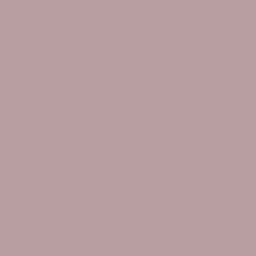

In [17]:
mean_rgb = average_rgb("sw-guidance/generation_v40/0.png")
print(mean_rgb)
box = rgb_box(mean_rgb)
display(box)

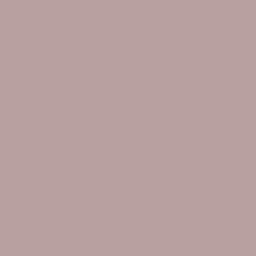

In [15]:
mean_rgb = average_rgb("sw-guidance/generation_v40/_0.png")
box = rgb_box(mean_rgb)
display(box)

[0.72086893 0.61495558 0.62494956]


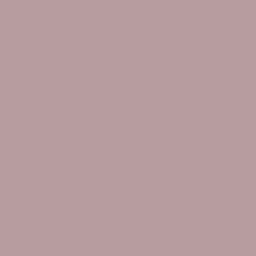

In [2]:
mean_rgb = average_rgb("sw-guidance/assets/pastel.jpeg")
box = rgb_box(mean_rgb)
print(mean_rgb)
display(box)

[0.7141947  0.60224567 0.61707044]


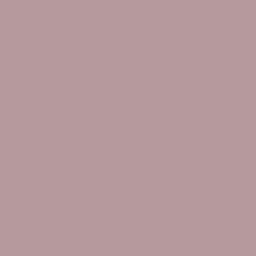

In [21]:
mean_rgb = average_rgb(r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\SDModelDebiasing\ITI-GEN\outputs\fixed_guidance2\steps\Male_negative_MSTESkin_tone_2_ctrl0_iter0_step37.png")
box = rgb_box(mean_rgb)
print(mean_rgb)
display(box)

[0.65165899 0.54607934 0.57723915]


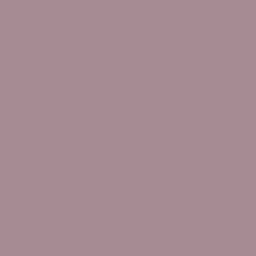

In [14]:
mean_rgb = average_rgb("C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\SDModelDebiasing\ITI-GEN_ControlNet_Colour\Male_positive_MSTESkin_tone_1\\00001_ctrl0.png")
box = rgb_box(mean_rgb)
print(mean_rgb)
display(box)

In [2]:
import torch
print("torch:", torch.__version__)
print("cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())

torch: 2.4.0+cu121
cuda: 12.1
cuda available: True


[0.6771613  0.54460968 0.54785791]


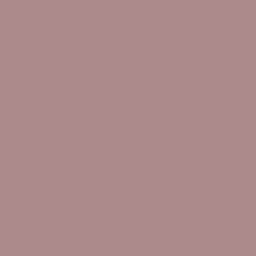

In [36]:
mean_rgb = average_rgb("C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\SDModelDebiasing\ITI-GEN\outputs\color_only\steps\Male_negative_MSTESkin_tone_10_iter0_step050.png")
box = rgb_box(mean_rgb)
print(mean_rgb)
display(box)

[0.67007038 0.52602602 0.5735643 ]


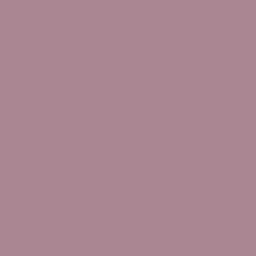

In [47]:
mean_rgb = average_rgb("C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\SDModelDebiasing\ITI-GEN\outputs\color_only\steps\Male_negative_MSTESkin_tone_10_iter2_step050.png")
box = rgb_box(mean_rgb)
print(mean_rgb)
display(box)

[0.67023125 0.53379897 0.58238974]


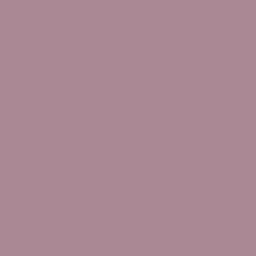

In [42]:
mean_rgb = average_rgb(r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\SDModelDebiasing\ITI-GEN\outputs\color_only\Male_negative_MSTESkin_tone_10\00087_ctrl0.png")
box = rgb_box(mean_rgb)
print(mean_rgb)
display(box)

[0.71054661 0.62243817 0.6066632 ]


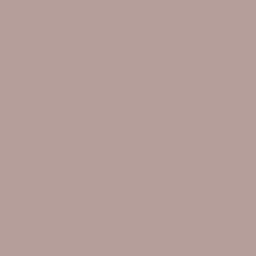

In [70]:
mean_rgb = average_rgb(r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\SDModelDebiasing\ITI-GEN\outputs\zeroshot_pred\Male_negative_MSTESkin_tone_10\00047_ctrl0.png")
box = rgb_box(mean_rgb)
print(mean_rgb)
display(box)

[0.68487283 0.58973175 0.58170929]


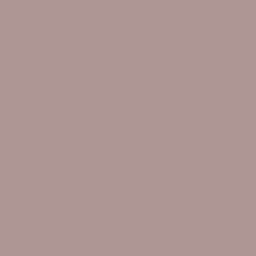

In [67]:
mean_rgb = average_rgb(r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\SDModelDebiasing\ITI-GEN\outputs\zeroshot_pred\Male_negative_MSTESkin_tone_10\00020_ctrl0.png")
box = rgb_box(mean_rgb)
print(mean_rgb)
display(box)

[0.70844408 0.60514137 0.6014965 ]


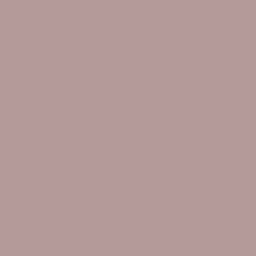

In [66]:
mean_rgb = average_rgb(r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\SDModelDebiasing\ITI-GEN\outputs\zeroshot_pred\Male_negative_MSTESkin_tone_10\00023_ctrl0.png")
box = rgb_box(mean_rgb)
print(mean_rgb)
display(box)